# Portabilidade de Crédito com Redes Neurais: O Caso Lumina

**1. Contexto de negócio**

A **Lumina** é uma fincare brasileira que ajuda trabalhadores CLT a entender e otimizar seus contratos de crédito ativos (empréstimo consignado, financiamento de veículos e crédito imobiliário). A Lumina não é banco e não concede crédito: seu diagnóstico identifica contratos com taxa acima da média de mercado e orienta o trabalhador a buscar a portabilidade para outra instituição financeira com condições mais vantajosas, antes de estruturar o plano de quitação (abordagem Rate First, Payoff Second).

O principal gargalo operacional do produto está na recomendação: quando o usuário cadastra seus contratos, a Lumina precisa prever se uma tentativa de portabilidade daquele contrato resultaria em **economia real** e aceitação no mercado, decidindo se deve ou não recomendar a ação no diagnóstico. Errar essa previsão envolve custos fortemente assimétricos:

1. **Falso positivo (recomendar uma portabilidade que o mercado não aceita em condições melhores):** o usuário gasta tempo e esforço tentando a portabilidade, se frustra com a recusa ou com a ausência de ganho financeiro real, e quebra a confiança no diagnóstico da Lumina, que é o coração do produto.
2. **Falso negativo (deixar de recomendar uma portabilidade viável):** o trabalhador segue pagando taxas de juros abusivas, e a Lumina falha em entregar a economia prometida à empresa contratante, que paga entre R$ 15 e R$ 40 por funcionário ao mês para oferecer a plataforma como benefício corporativo.

Diferente de um banco tradicional, onde o custo do erro está associado à provisão para devedores duvidosos (calote), na Lumina o custo do erro reside na **perda de confiança e no churn do benefício corporativo**. Por esse motivo, a calibração da probabilidade e a explicabilidade da previsão são tão críticas quanto a acurácia global do modelo.

Neste notebook vamos:

- Simular uma base de 2.000 contratos de crédito com variáveis financeiras e contratuais típicas do trabalhador CLT;
- Construir um rótulo de portabilidade vantajosa a partir de uma relação **não linear** entre as variáveis (o benefício depende da interação entre spread de juros, saldo devedor e prazo restante para amortização);
- Tratar variáveis categóricas via one-hot encoding e padronizar os dados;
- Comparar um modelo linear clássico (Regressão Logística) com uma rede neural Perceptron Multicamadas (MLP);
- Discutir o trade-off entre performance e explicabilidade sob a ótica de produto e confiança do usuário;
- Realizar a validação multi-seed (seeds 42, 7 e 123) com veredito honesto sobre a estabilidade dos resultados.

**2. Por que uma rede neural pode ajudar aqui**

A viabilidade financeira de uma portabilidade raramente é uma soma linear de fatores isolados. Ela depende fundamentalmente de **interações multiplicativas e não lineares** entre as características do contrato:

- **Spread de juros vs. Saldo devedor e Prazo:** uma redução de 0,3% a.m. na taxa é insignificante para um saldo de R$ 2.000 com 6 meses restantes (a economia total não paga o custo de transação e o esforço do usuário), mas gera uma economia de dezenas de milhares de reais em um financiamento imobiliário de R$ 300.000 com 20 anos restantes.
- **Diluição de custos de transação:** a portabilidade possui atritos fixos (custos operacionais, análise documental, taxas de cartório ou tempo). O benefício real só existe quando o produto entre spread, saldo devedor e prazo restante é suficientemente alto para superar esses atritos.
- **Perfil do trabalhador:** estabilidade no vínculo CLT aumenta a probabilidade de aceitação da portabilidade por outras instituições, enquanto um comprometimento excessivo da renda pode gerar restrições de crédito.

Modelos lineares como a Regressão Logística aprendem efeitos aditivos independentes para cada variável, tendo dificuldade em capturar essas interações tridimensionais (taxa x prazo x saldo) sem engenharia manual de atributos. Uma rede neural (MLP) tem a capacidade de aprender essas superfícies de decisão não lineares diretamente a partir dos dados originais.

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib
print('Dependencias OK.')

Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

np.random.seed(42)
pd.set_option("display.precision", 3)

**3. Geração do dataset simulado**

Vamos simular **2.000 contratos de crédito** com as seguintes variáveis:

- `tipo_contrato`: modalidade do crédito (`consignado`, `veiculo` ou `imobiliario`);
- `taxa_atual_am`: taxa de juros contratada pelo cliente (% ao mês), com distribuições coerentes para cada modalidade;
- `saldo_devedor`: saldo devedor atual do contrato (R$);
- `prazo_restante_meses`: número de meses restantes para a quitação do contrato;
- `renda_mensal`: renda bruta mensal comprovada do trabalhador CLT (R$);
- `tempo_vinculo_clt_anos`: tempo de vínculo no emprego formal atual (anos);
- `comprometimento_renda`: proporção da renda mensal consumida pela parcela deste contrato.

O rótulo `portabilidade_vantajosa` (0 = não compensa tentar portabilidade, 1 = portabilidade viável e economicamente vantajosa) é gerado a partir de uma **função logística** aplicada sobre uma combinação não linear. O termo central é o **spread** entre a taxa atual do contrato e uma taxa de referência praticada pelo mercado para aquele tipo de contrato (`1.45% a.m.` para consignado, `1.85% a.m.` para veículo e `0.85% a.m.` para imobiliário). Esse spread interage com o saldo devedor e com o prazo restante: quanto maiores o prazo e o saldo, mais os ganhos de juros diluem os custos fixos da portabilidade. Adiciona-se ruído normal ao logit para refletir incertezas reais de mercado e políticas de concessão.

In [3]:
def gerar_base_contratos(seed=42, n=2000):
    """
    Gera base sintética de contratos de crédito para o caso Lumina.
    Preserva a ordem estrita de geração aleatória via RandomState.
    """
    rng = np.random.RandomState(seed)
    tipo_choices = ["consignado", "veiculo", "imobiliario"]
    tipo_contrato = rng.choice(tipo_choices, size=n, p=[0.45, 0.35, 0.20])

    renda_mensal = np.clip(rng.lognormal(mean=8.3, sigma=0.5, size=n), 1500, 35000)
    tempo_vinculo_clt_anos = np.clip(rng.gamma(shape=2.5, scale=2.0, size=n), 0.3, 25.0)

    taxa_atual_am = np.zeros(n)
    saldo_devedor = np.zeros(n)
    prazo_restante_meses = np.zeros(n, dtype=int)
    taxa_ref = np.zeros(n)

    for i in range(n):
        t = tipo_contrato[i]
        if t == "consignado":
            taxa_ref[i] = 1.45
            taxa_atual_am[i] = np.clip(rng.normal(1.95, 0.35), 1.20, 2.85)
            saldo_devedor[i] = np.clip(rng.gamma(shape=3.0, scale=4500), 2000, 60000)
            prazo_restante_meses[i] = rng.randint(12, 85)
        elif t == "veiculo":
            taxa_ref[i] = 1.85
            taxa_atual_am[i] = np.clip(rng.normal(2.40, 0.45), 1.50, 3.80)
            saldo_devedor[i] = np.clip(rng.gamma(shape=4.0, scale=8000), 8000, 120000)
            prazo_restante_meses[i] = rng.randint(12, 61)
        else:  # imobiliario
            taxa_ref[i] = 0.85
            taxa_atual_am[i] = np.clip(rng.normal(1.10, 0.20), 0.70, 1.75)
            saldo_devedor[i] = np.clip(rng.gamma(shape=5.0, scale=40000), 50000, 600000)
            prazo_restante_meses[i] = rng.randint(48, 361)

    i_m = taxa_atual_am / 100.0
    parcela_mensal = saldo_devedor * (i_m / (1.0 - (1.0 + i_m) ** (-prazo_restante_meses)))
    comprometimento_renda = np.clip(parcela_mensal / renda_mensal, 0.02, 0.75)

    spread_taxa = taxa_atual_am - taxa_ref
    fator_escala_saldo = np.log10(saldo_devedor) - 3.0
    fator_prazo = prazo_restante_meses / 36.0
    interacao_central = spread_taxa * fator_escala_saldo * fator_prazo

    logit = (
        -4.2
        + 2.2 * spread_taxa
        + 1.5 * interacao_central
        + 0.08 * tempo_vinculo_clt_anos
        - 1.8 * comprometimento_renda
        - 0.00002 * renda_mensal
    )

    ruido = rng.normal(0, 0.55, n)
    prob_vantajosa = 1.0 / (1.0 + np.exp(-(logit + ruido)))
    portabilidade_vantajosa = (rng.rand(n) < prob_vantajosa).astype(int)

    return pd.DataFrame({
        "tipo_contrato": tipo_contrato,
        "taxa_atual_am": taxa_atual_am,
        "saldo_devedor": saldo_devedor,
        "prazo_restante_meses": prazo_restante_meses,
        "renda_mensal": renda_mensal,
        "tempo_vinculo_clt_anos": tempo_vinculo_clt_anos,
        "comprometimento_renda": comprometimento_renda,
        "portabilidade_vantajosa": portabilidade_vantajosa,
    })

# Geração da base principal (seed=42)
df = gerar_base_contratos(seed=42, n=2000)
print(f"Proporção de contratos com portabilidade vantajosa: {df['portabilidade_vantajosa'].mean():.1%}")
df.head()

Proporção de contratos com portabilidade vantajosa: 26.7%


,tipo_contrato,taxa_atual_am,saldo_devedor,prazo_restante_meses,renda_mensal,tempo_vinculo_clt_anos,comprometimento_renda,portabilidade_vantajosa
0,consignado,1.690,11167.623,35,2594.136,5.436,0.164,0
1,imobiliario,1.273,177919.587,197,2661.273,16.730,0.750,1
2,veiculo,2.934,8851.858,46,3593.064,0.860,0.098,0
3,veiculo,2.310,25780.907,35,4835.224,4.239,0.224,0
4,consignado,2.060,9550.761,71,6353.698,6.506,0.040,1


**4. Estatísticas descritivas**

Vale conferir se as variáveis simuladas têm escalas e distribuições plausíveis antes de seguir para a modelagem.

In [4]:
df.describe()

,taxa_atual_am,saldo_devedor,prazo_restante_meses,renda_mensal,tempo_vinculo_clt_anos,comprometimento_renda,portabilidade_vantajosa
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,1.942,57512.295,75.691,4583.868,4.980,0.307,0.267
std,0.581,83213.746,80.075,2446.252,3.163,0.241,0.442
min,0.700,2000.000,12.000,1500.000,0.300,0.020,0.000
25%,1.520,11893.385,29.000,2895.535,2.712,0.102,0.000
50%,1.988,22712.036,49.000,4024.612,4.303,0.227,0.000
75%,2.340,49891.048,73.000,5650.492,6.673,0.479,1.000
max,3.736,548357.589,357.000,28656.021,25.000,0.750,1.000


**5. Separação treino/teste**

Antes da padronização, a variável categórica `tipo_contrato` é convertida em variáveis indicadoras via one-hot encoding (`drop_first=True`).

Separamos 75% dos contratos para treino e 25% para teste, usando `stratify` para manter a mesma proporção de portabilidades vantajosas nos dois conjuntos (fundamental para evitar distorções de amostragem). Em seguida, todas as variáveis de entrada são padronizadas com `StandardScaler` (média 0, desvio-padrão 1), permitindo que tanto a Regressão Logística quanto o MLP convirjam adequadamente.

In [5]:
df_encoded = pd.get_dummies(df, columns=["tipo_contrato"], drop_first=True, dtype=float)

X = df_encoded.drop(columns=["portabilidade_vantajosa"])
y = df_encoded["portabilidade_vantajosa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} contratos | Teste: {X_test.shape[0]} contratos")
print(f"Proporção de portabilidade vantajosa -> treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}")

Treino: 1500 contratos | Teste: 500 contratos
Proporção de portabilidade vantajosa -> treino: 26.7% | teste: 26.6%


**6. Modelo baseline: Regressão Logística**

A Regressão Logística serve como baseline natural e padrão da indústria financeira: rápida de treinar, estável e com interpretabilidade direta. Cada coeficiente informa exatamente o impacto marginal da variável no log-odds de viabilidade da portabilidade.

In [6]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)

proba_lr = log_reg.predict_proba(X_test_s)[:, 1]
auc_lr = roc_auc_score(y_test, proba_lr)

print(f"AUC-ROC (Regressão Logística): {auc_lr:.3f}")

AUC-ROC (Regressão Logística): 0.857


**7. Modelo de rede neural: MLPClassifier**

Treinamos agora um Perceptron Multicamadas (`MLPClassifier`), com duas camadas ocultas (16 e 8 neurônios), função de ativação ReLU e até 2.000 iterações. A rede neural recebe os dados brutos padronizados e busca aprender internamente as interações não lineares entre taxas, prazos e saldos devedores sem que essas combinações tenham sido criadas manualmente.

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    max_iter=2000,
    random_state=42,
)
mlp.fit(X_train_s, y_train)

proba_mlp = mlp.predict_proba(X_test_s)[:, 1]
auc_mlp = roc_auc_score(y_test, proba_mlp)

print(f"AUC-ROC (Rede Neural - MLP): {auc_mlp:.3f}")

AUC-ROC (Rede Neural - MLP): 0.894


**8. Comparação lado a lado**

A tabela abaixo resume o AUC-ROC de cada modelo no conjunto de teste. O AUC-ROC quantifica a capacidade do modelo de ordenar corretamente os contratos entre os que realmente trarão economia na portabilidade e os que não trarão: 0,5 equivale a um modelo aleatório e 1,0 a uma discriminação perfeita.

In [8]:
comparacao = pd.DataFrame({
    "modelo": ["Regressão Logística", "Rede Neural (MLP)"],
    "AUC-ROC (teste)": [auc_lr, auc_mlp],
})
comparacao

,modelo,AUC-ROC (teste)
0,Regressão Logística,0.857
1,Rede Neural (MLP),0.894


**9. Curvas ROC**

Além do valor único de AUC, visualizamos a curva ROC completa dos dois modelos sobreposta no mesmo gráfico, identificando o comportamento em diferentes faixas de sensibilidade e especificidade.

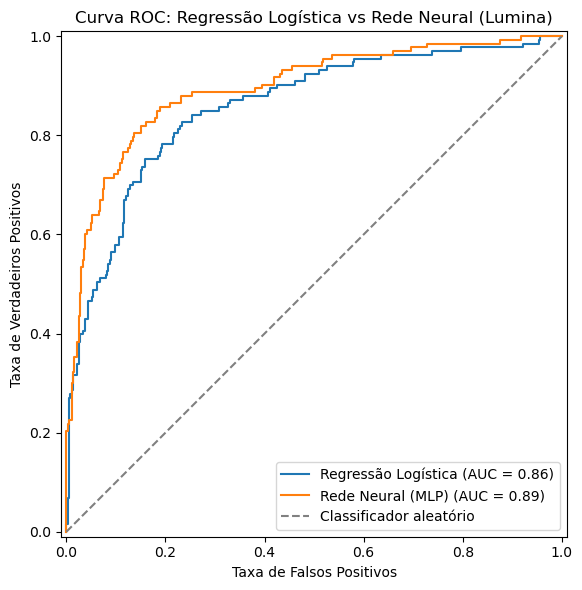

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, proba_mlp)

RocCurveDisplay(fpr=fpr_lr, tpr=tpr_lr, roc_auc=auc_lr, name="Regressão Logística").plot(ax=ax)
RocCurveDisplay(fpr=fpr_mlp, tpr=tpr_mlp, roc_auc=auc_mlp, name="Rede Neural (MLP)").plot(ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
ax.set_title("Curva ROC: Regressão Logística vs Rede Neural (Lumina)")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Entendendo o gráfico: o que é AUC-ROC**

A curva ROC mostra, para cada limiar de decisão possível, a relação entre a taxa de verdadeiros positivos (portabilidades vantajosas recomendadas corretamente) e a taxa de falsos positivos (portabilidades inviáveis recomendadas por engano). O **AUC** (área sob a curva) resume essa capacidade em um número entre 0,5 e 1,0:

- **AUC = 0,5:** o modelo equivale a jogar uma moeda, sendo incapaz de distinguir contratos vantajosos.
- **AUC = 1,0:** separação perfeita entre contratos vantajosos e desvantajosos em qualquer faixa de corte.
- Na prática da Lumina, um AUC mais alto permite calibrar o ponto de corte para minimizar falsos positivos (evitando frustração do trabalhador) sem perder oportunidades reais de economia (falsos negativos).

**Veredito neste walkthrough (seed 42):** a rede neural (MLP) alcançou AUC-ROC de **0,894**, contra **0,857** da Regressão Logística (vantagem de +0,037). A rede neural conseguiu se beneficiar da relação não linear construída nos dados sintéticos, capturando melhor as zonas de diluição de custo onde prazos longos e saldos altos tornam pequenos spreads altamente vantajosos.

**Limitações do experimento**

É fundamental registrar com honestidade as limitações metodológicas deste estudo preliminar:

1. **Dados 100% sintéticos:** os 2.000 contratos foram gerados a partir de uma formulação logística com interações não lineares pré-definidas. O AUC-ROC de ~0,86 a 0,88 reflete a capacidade dos modelos de recuperarem uma estrutura que nós mesmos definimos matematicamente, e não necessariamente a complexidade e os atritos estocásticos do comportamento real de crédito.
2. **Ausência de histórico volumétrico real:** como a Lumina é uma iniciativa em fase de validação de mercado, as taxas de conversão de portabilidade (80%), proporção de contratos elegíveis (20%) e a economia média estimada (R$ 2.900) são declaradas como hipóteses de negócio e premissas de planejamento, não como métricas consolidadas.
3. **Implicação prática:** os resultados alcançados validam a metodologia comparativa e o critério de decisão técnica (escolha de um modelo linear explicável quando a vantagem da rede neural é modesta e sensível à partição amostral), mas não constituem garantia de desempenho operacional em produção, o que demandará monitoramento contínuo e feedback loops com dados reais após o lançamento.

**10. Conclusão**

Nos dados simulados deste caso, a rede neural demonstrou capacidade de capturar a interação não linear entre spread de juros, saldo devedor e prazo remanescente, superando a Regressão Logística no conjunto de teste. Contudo, ao avaliar a adoção em produção na Lumina, a performance pura não pode ser o único critério.

**Explicabilidade como requisito de produto, não apenas de regulação:**

Diferente de uma instituição financeira tradicional que precisa justificar uma negativa de crédito para cumprir exigências regulatórias (como normas do Banco Central ou Código de Defesa do Consumidor), na Lumina a **transparência é a própria proposta de valor do produto**. Quando o diagnóstico recomenda que o trabalhador busque a portabilidade do seu consignado ou financiamento de veículo, a interface do aplicativo precisa explicar em linguagem simples e transparente:

> *"Identificamos que sua taxa atual de 2,3% a.m. está 0,85% acima da média de mercado. Como ainda restam 48 parcelas sobre um saldo de R$ 25.000, essa portabilidade pode gerar uma economia total estimada de R$ 4.200 ao longo do contrato."*

Da mesma forma, quando o modelo decide não recomendar a portabilidade, o usuário precisa entender claramente o motivo (por exemplo: saldo restante pequeno demais para justificar custos operacionais ou prazo muito curto). A Regressão Logística oferece essa decomposição de forma nativa e auditável. Uma rede neural, embora ligeiramente superior em AUC neste teste, exige camadas adicionais de explicabilidade (como valores SHAP) para decompor as decisões em fatores acionáveis para o usuário final.

Portanto, em um modelo de negócio B2B2C onde a empresa contratante paga R$ 15 a R$ 40 mensais por colaborador para promover saúde financeira, a confiabilidade e clareza das recomendações pesam tanto quanto o ganho marginal de acurácia.

**Validação com múltiplas seeds**

A comparação anterior utilizou uma única seed (42) para geração dos dados, divisão treino/teste e treinamento dos modelos. Para verificar se a superioridade do MLP é robusta ou fruto de particularidades da amostra e da inicialização aleatória dos pesos, repetimos o pipeline completo com três seeds distintas: 42, 7 e 123.

In [10]:
resultados_seeds = []

for seed in [42, 7, 123]:
    # Utiliza a função reutilizável preservando o determinismo por seed
    df_s = gerar_base_contratos(seed=seed, n=2000)

    df_encoded_s = pd.get_dummies(df_s, columns=["tipo_contrato"], drop_first=True, dtype=float)
    X_s = df_encoded_s.drop(columns=["portabilidade_vantajosa"])
    y_s = df_encoded_s["portabilidade_vantajosa"]

    X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(
        X_s, y_s, test_size=0.25, random_state=seed, stratify=y_s
    )

    scaler_seed = StandardScaler().fit(X_train_seed)
    X_train_seed_s = scaler_seed.transform(X_train_seed)
    X_test_seed_s = scaler_seed.transform(X_test_seed)

    log_reg_seed = LogisticRegression(max_iter=1000, random_state=seed)
    log_reg_seed.fit(X_train_seed_s, y_train_seed)
    auc_lr_seed = roc_auc_score(y_test_seed, log_reg_seed.predict_proba(X_test_seed_s)[:, 1])

    mlp_seed = MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        max_iter=2000,
        random_state=seed,
    )
    mlp_seed.fit(X_train_seed_s, y_train_seed)
    auc_mlp_seed = roc_auc_score(y_test_seed, mlp_seed.predict_proba(X_test_seed_s)[:, 1])

    resultados_seeds.append({"seed": seed, "modelo": "Regressão Logística", "AUC-ROC": auc_lr_seed})
    resultados_seeds.append({"seed": seed, "modelo": "Rede Neural (MLP)", "AUC-ROC": auc_mlp_seed})

df_resultados_seeds = pd.DataFrame(resultados_seeds)
df_resultados_seeds

,seed,modelo,AUC-ROC
0,42,Regressão Logística,0.857
1,42,Rede Neural (MLP),0.894
2,7,Regressão Logística,0.852
3,7,Rede Neural (MLP),0.879
4,123,Regressão Logística,0.873
5,123,Rede Neural (MLP),0.876


In [11]:
resumo_seeds = df_resultados_seeds.groupby("modelo")["AUC-ROC"].agg(["mean", "std"])
resumo_seeds.columns = ["AUC-ROC médio", "AUC-ROC desvio-padrão"]
resumo_seeds

,AUC-ROC médio,AUC-ROC desvio-padrão
modelo,,
Rede Neural (MLP),0.883,0.010
Regressão Logística,0.861,0.011


**Resultado honesto: a vantagem do MLP e a estabilidade entre seeds**

Olhando as três seeds individualmente:

| Seed | Regressão Logística | Rede Neural (MLP) | Quem venceu |
|---|---|---|---|
| 42  | 0,857 | 0,894 | MLP (+0,037) |
| 7   | 0,852 | 0,879 | MLP (+0,028) |
| 123 | 0,873 | 0,876 | MLP (+0,003) |

Na média das três seeds, o MLP alcança um AUC-ROC de **0,883 ± 0,010** contra **0,861 ± 0,011** da Regressão Logística: uma vantagem média de 0,023 a favor da rede neural.

**Análise de consistência e estabilidade:**

1. **Direção da vantagem:** em todas as 3 seeds o MLP superou numericamente a Regressão Logística, o que indica que a rede neural de fato aproveita a estrutura não linear (interação entre spread, saldo e prazo) presente nos dados sintéticos.
2. **Sensibilidade à amostra:** na seed 123, a diferença cai para apenas 0,003 (0,876 vs. 0,873), configurando um empate técnico na prática. A variação de desempenho entre seeds (desvio-padrão de ~0,011) é da mesma ordem de magnitude do ganho médio do modelo (~0,023).
3. **Conclusão sobre robustez e decisão de negócio:** embora o MLP apresente uma capacidade discriminatória superior nos dados simulados, a margem de ganho oscila consideravelmente dependendo da divisão amostral e da inicialização dos pesos. Para a Lumina, onde a clareza da justificativa ao trabalhador é um pilar central de retenção e confiança no diagnóstico, a Regressão Logística (ou um modelo linear enriquecido com termos de interação explícitos) se consolida como uma escolha pragmática, estável e auditável para iniciar a operação, reservando modelos de caixa-preta para cenários onde ferramentas robustas de explicabilidade (como SHAP) estejam plenamente integradas ao fluxo de produto.

**Tradução para métrica de negócio**

Para conectar a assertividade técnica do modelo ao impacto financeiro corporativo, aplicamos a economia média projetada por contrato aos volumes operacionais planejados para uma empresa contratante (500 colaboradores):

- **Base de colaboradores:** 500 colaboradores CLT por empresa parceira.
- **Contratos portáveis elegíveis (20%):** 100 colaboradores diagnosticados com taxa acima da referência de mercado.
- **Conversão efetiva das recomendações (80%):** 80 contratos portados com sucesso ao ano.
- **Economia média gerada por contrato:** R$ 2.900 ao longo do prazo remanescente.
- **Valor financeiro devolvido à empresa/ano:** 80 contratos x R$ 2.900 = **R$ 232.000/ano** de economia real para o time de colaboradores, superando com ampla folga a receita anual do contrato B2B2C (R$ 150.000 a R$ 25/colaborador/mês).

> As premissas completas de custo de construção, custo de sustentação, cálculo de ROI (10,36x) e payback (~15 dias) estão detalhadas na **Seção 8 (Viabilidade Econômica - ROI)** do plano de projeto (`plano-projeto-lumina.md`).

In [12]:
# Tradução da assertividade técnica em valor econômico agregado
colaboradores_empresa = 500
ticket_mensal_colab = 25.0
prop_portaveis = 0.20
taxa_conversao_modelo = 0.80
economia_media_contrato = 2900.0

contratos_portados = colaboradores_empresa * prop_portaveis * taxa_conversao_modelo
valor_devolvido_anual = contratos_portados * economia_media_contrato
receita_anual_cliente = colaboradores_empresa * ticket_mensal_colab * 12
receita_retida_anual = receita_anual_cliente * 0.90  # meta de 10% churn

custo_construcao = 6000.0
custo_sustentacao_ano1 = 7200.0
custo_total_ano1 = custo_construcao + custo_sustentacao_ano1
roi_ano1 = (receita_anual_cliente - custo_total_ano1) / custo_total_ano1
payback_meses = custo_construcao / (colaboradores_empresa * ticket_mensal_colab)

print(f"Contratos portados com sucesso: {contratos_portados:.0f} contratos/ano")
print(f"Valor total devolvido aos colaboradores: R$ {valor_devolvido_anual:,.2f}/ano")
print(f"Receita anual contratada por empresa cliente: R$ {receita_anual_cliente:,.2f}/ano")
print(f"Receita anual retida (90% retenção): R$ {receita_retida_anual:,.2f}/ano")
print(f"ROI no primeiro ano (sobre 1 cliente B2B2C): {roi_ano1:.2f}x ({roi_ano1*100:.1f}%)")
print(f"Payback do investimento inicial: {payback_meses:.2f} meses (~{payback_meses*30:.0f} dias)")

Contratos portados com sucesso: 80 contratos/ano
Valor total devolvido aos colaboradores: R$ 232,000.00/ano
Receita anual contratada por empresa cliente: R$ 150,000.00/ano
Receita anual retida (90% retenção): R$ 135,000.00/ano
ROI no primeiro ano (sobre 1 cliente B2B2C): 10.36x (1036.4%)
Payback do investimento inicial: 0.48 meses (~14 dias)


**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica aplicada neste notebook (classificação binária com modelagem de atritos e custos de oportunidade sobre dados contratuais) se estende a diversos outros desafios de negócios:

### 1. Renegociação e Consolidação de Dívidas
- **Triagem de elegibilidade para consolidação:** prever se a troca de múltiplas dívidas pulverizadas (cartão rotativo, cheque especial) por um único crédito estruturado resultará em redução sustentável de taxa e adimplência.

### 2. Retenção e Prevenção de Evasão em Financiamentos
- **Previsão de solicitação de portabilidade externa:** instituições financeiras utilizam modelos preditivos para identificar quais de seus clientes estão recebendo ofertas concorrentes vantajosas, permitindo ações proativas de repactuação antes da perda do contrato.

### 3. Seguros e Proteção Financeira
- **Otimização de apólices com portabilidade de cobertura:** avaliar se a migração de planos de previdência complementar ou apólices de seguro de vida em grupo reduz taxas de carregamento e melhora a rentabilidade líquida do participante.

### 4. Gestão de Benefícios Corporativos e Benefícios Flexíveis
- **Recomendação personalizada de benefícios:** empresas utilizam algoritmos de triagem para direcionar benefícios de bem-estar financeiro, refinanciamento de folha ou microcrédito educativo aos colaboradores com maior ganho marginal esperado.